# General Analysis: Regression Evidence for Scarcity in Cinema

**Research question:** under what conditions does scarcity in cinema operate as a symbolic signal of artistic value and social distinction, rather than simply as a distribution or access constraint?

This notebook follows the uploaded regression plan. It estimates associations between theatrical scarcity indicators and four outcome families:

1. perceived artistic/audience value, proxied by IMDb rating;
2. sustained theatrical demand, proxied by box-office legs;
3. commercial scale, proxied by worldwide box office;
4. commercial efficiency, proxied by worldwide ROI.

The analysis is explicitly **associational, not causal**. Platform release, limited release, and expansion are constructed proxies from theater counts. They do not directly observe festival prestige, marketing discourse, audience status interpretation, IMAX/70mm scarcity, sold-out screenings, or streaming-window strategy.

**Execution note:** this notebook was executed with the existing `data-science` conda environment because the base Python kernel on this machine does not include `pandas`, `statsmodels`, and the plotting libraries needed for the analysis.


In [1]:
import os
import warnings
from pathlib import Path

# Keep matplotlib cache in a writable temporary directory.
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/movie_scarcity_mpl")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display, Markdown
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_PATH = PROJECT_ROOT / "data_final" / "top_movies_imdb_final.csv"
OUT_DIR = PROJECT_ROOT / "figures_analysis"
OUT_DIR.mkdir(exist_ok=True)

artifact_records = []

def rel(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def register_artifact(path, kind, description):
    artifact_records.append({"artifact": rel(path), "type": kind, "description": description})

def save_figure(fig, name, description):
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    register_artifact(path, "figure", description)
    print(f"Saved figure: {rel(path)}")
    return path

def save_table(table, name, description, index=False):
    csv_path = OUT_DIR / f"{name}.csv"
    html_path = OUT_DIR / f"{name}.html"
    table.to_csv(csv_path, index=index)
    table.to_html(html_path, index=index, border=0)
    register_artifact(csv_path, "table_csv", description)
    register_artifact(html_path, "table_html", description)
    print(f"Saved table: {rel(csv_path)}")
    print(f"Saved table: {rel(html_path)}")
    return table

def save_text(text, name, description):
    path = OUT_DIR / f"{name}.txt"
    path.write_text(text, encoding="utf-8")
    register_artifact(path, "text", description)
    print(f"Saved text: {rel(path)}")
    return path

def p_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.1:
        return "+"
    return ""

def collapse_rare(series, min_count=30, other_label="Other"):
    clean = series.fillna("Unknown").astype(str).str.strip()
    counts = clean.value_counts(dropna=False)
    keep = counts[counts >= min_count].index
    return clean.where(clean.isin(keep), other_label)

raw = pd.read_csv(DATA_PATH)
print(f"Loaded {rel(DATA_PATH)}")
print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]:,}")
display(raw.head())


Loaded data_final/top_movies_imdb_final.csv
Rows: 3,959
Columns: 40


,movie_name,release_date,production_budget_usd,domestic_gross_usd,worldwide_gross_usd,domestic_box_office_usd,international_box_office_usd,worldwide_box_office_usd,opening_weekend_usd,legs,infl_adj_dom_bo_usd,mpaa_rating,running_time_minutes,source,genre,production_method,creative_type,domestic_share_percentage,release_year,release_month,release_quarter,opening_theaters,max_theaters,avg_weeks_per_theater,is_franchise,profit_worldwide,profit_domestic,roi_worldwide,roi_domestic,log_domestic_box_office,log_worldwide_box_office,log_budget,log_opening_weekend,log_opening_theaters,log_max_theaters,imdb_id,imdb_rating,imdb_votes,imdb_rating_num,imdb_votes_num
0,Avatar: The Way of Water,2022-12-09,460000000,684075767,2315589775,"684,075,767.0000","1,631,514,008.0000","2,315,589,775.0000","134,100,226.0000",5.1000,"693,596,368.0000",PG-13,190.0000,Original Screenplay,Action,"Animation,Live Action",Science Fiction,29.5000,"2,022.0000",12.0000,4.0000,"4,202.0000","4,340.0000",11.1000,1,"1,855,589,775.0000","224,075,767.0000",5.0339,1.4871,20.3436,21.5629,19.9467,18.7141,8.3436,8.3759,tt1630029,7.5000,"601,100",7.5000,"601,100.0000"
1,Indiana Jones and the Dial of Destiny,2023-06-28,402300000,174480468,383963057,"174,480,468.0000","209,482,589.0000","383,963,057.0000","60,368,101.0000",2.8900,"174,480,468.0000",PG-13,142.0000,Original Screenplay,Adventure,Live Action,Historical Fiction,45.4000,"2,023.0000",6.0000,2.0000,"4,600.0000","4,600.0000",4.6000,1,"-18,336,943.0000","-227,819,532.0000",0.9544,0.4337,18.9773,19.7661,19.8127,17.9160,8.4340,8.4340,tt1462764,6.5000,"230,035",6.5000,"230,035.0000"
2,Avengers: Endgame,2019-04-23,400000000,858373000,2748242781,"858,373,000.0000","1,889,869,781.0000","2,748,242,781.0000","357,115,007.0000",2.4000,"1,010,181,328.0000",PG-13,181.0000,Based on Comic/Graphic Novel,Action,"Animation,Live Action",Super Hero,31.2000,"2,019.0000",4.0000,2.0000,"4,662.0000","4,662.0000",8.1000,1,"2,348,242,781.0000","458,373,000.0000",6.8706,2.1459,20.5705,21.7342,19.8070,19.6936,8.4474,8.4474,tt4154796,8.4000,"1,442,446",8.4000,"1,442,446.0000"
3,Pirates of the Caribbean: On Stranger Tides,2011-05-20,379000000,241071802,1045713802,"241,071,802.0000","804,642,000.0000","1,045,713,802.0000","90,151,958.0000",2.6700,"327,711,731.0000",PG-13,136.0000,Based on Theme Park Ride,Adventure,Live Action,Historical Fiction,23.1000,"2,011.0000",5.0000,2.0000,"4,155.0000","4,164.0000",6.0000,1,"666,713,802.0000","-137,928,198.0000",2.7591,0.6361,19.3006,20.7680,19.7530,18.3170,8.3323,8.3345,tt1298650,6.6000,"606,603",6.6000,"606,603.0000"
4,Avengers: Age of Ultron,2015-04-22,365000000,459005868,1395316979,"459,005,868.0000","936,311,111.0000","1,395,316,979.0000","191,271,109.0000",2.4000,"586,961,233.0000",PG-13,141.0000,Based on Comic/Graphic Novel,Action,"Animation,Live Action",Super Hero,32.9000,"2,015.0000",4.0000,2.0000,"4,276.0000","4,276.0000",7.0000,1,"1,030,316,979.0000","94,005,868.0000",3.8228,1.2576,19.9446,21.0564,19.7154,19.0692,8.3610,8.3610,tt2395427,7.3000,"998,463",7.3000,"998,463.0000"


## 1. Regression Dataset Construction

The plan recommends log-transforming skewed variables, creating platform/limited/wide release indicators, measuring theater expansion, and capping extreme ROI. The definitions below keep the theoretical distinction clear:

- `log_opening_theaters`: initial access scale. Lower values imply higher initial scarcity.
- `platform_release`: opening in 100 or fewer theaters and eventually reaching at least 500 theaters.
- `log_expansion_ratio`: later reach relative to initial access. Higher values indicate platform-style expansion.
- `legs`: sustained demand after opening weekend.
- `roi_worldwide_capped`: commercial efficiency, capped at the 99th percentile to reduce extreme-outlier leverage.


In [2]:
df = raw.copy()

numeric_cols = [
    "production_budget_usd", "domestic_gross_usd", "worldwide_gross_usd",
    "domestic_box_office_usd", "international_box_office_usd", "worldwide_box_office_usd",
    "opening_weekend_usd", "legs", "infl_adj_dom_bo_usd", "running_time_minutes",
    "domestic_share_percentage", "release_year", "release_month", "release_quarter",
    "opening_theaters", "max_theaters", "avg_weeks_per_theater", "is_franchise",
    "profit_worldwide", "profit_domestic", "roi_worldwide", "roi_domestic",
    "log_domestic_box_office", "log_worldwide_box_office", "log_budget",
    "log_opening_weekend", "log_opening_theaters", "log_max_theaters",
    "imdb_rating_num", "imdb_votes_num",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Regular integer year is required by statsmodels formula handling.
df = df.dropna(subset=["release_year"]).copy()
df["release_year"] = df["release_year"].astype(int)
df["release_decade"] = (df["release_year"] // 10 * 10).astype(int).astype(str) + "s"
df["is_franchise"] = df["is_franchise"].fillna(0).astype(int)

# Collapse rare categories so fixed effects are interpretable and less prone to separation in binary models.
for col in ["genre", "source", "creative_type"]:
    df[f"{col}_fe"] = collapse_rare(df[col], min_count=30)

# Log transforms for skewed count and financial variables.
log_map = {
    "log_opening_theaters": "opening_theaters",
    "log_max_theaters": "max_theaters",
    "log_budget": "production_budget_usd",
    "log_worldwide_box_office": "worldwide_box_office_usd",
    "log_domestic_box_office": "domestic_box_office_usd",
    "log_opening_weekend": "opening_weekend_usd",
    "log_imdb_votes": "imdb_votes_num",
}
for new_col, source_col in log_map.items():
    df[new_col] = np.log1p(df[source_col])

# Theater rollout variables.
df["platform_release_ratio"] = df["opening_theaters"] / df["max_theaters"]
df["theater_expansion"] = df["max_theaters"] - df["opening_theaters"]
df["theater_expansion_ratio"] = df["max_theaters"] / df["opening_theaters"]
df["log_expansion_ratio"] = np.log1p(df["theater_expansion_ratio"])
df["log_theater_expansion"] = np.log1p(df["theater_expansion"].clip(lower=0))

# Regression flags from the plan.
df["platform_release"] = ((df["opening_theaters"] <= 100) & (df["max_theaters"] >= 500)).astype(int)
df["limited_release"] = (df["opening_theaters"] <= 100).astype(int)
df["wide_release"] = (df["opening_theaters"] >= 2000).astype(int)

# Missing IMDb ratings are left missing rather than treated as low ratings.
df["high_rating"] = np.where(df["imdb_rating_num"].notna(), (df["imdb_rating_num"] >= 7.0).astype(int), np.nan)

# Optional release-strategy label from the plan.
def classify_release(row):
    if row["opening_theaters"] <= 50 and row["max_theaters"] >= 500:
        return "Platform release"
    if row["opening_theaters"] <= 100:
        return "Limited release"
    if row["opening_theaters"] >= 2000:
        return "Wide release"
    return "Moderate release"

df["release_strategy"] = df.apply(classify_release, axis=1)

# Cap ROI for regression but keep the raw value in the dataset.
df["roi_worldwide_capped"] = df["roi_worldwide"].clip(upper=df["roi_worldwide"].quantile(0.99))
df = df.replace([np.inf, -np.inf], np.nan)

regression_cols = [
    "movie_name", "release_year", "release_decade", "genre", "source", "creative_type",
    "genre_fe", "source_fe", "creative_type_fe", "is_franchise",
    "opening_theaters", "max_theaters", "platform_release_ratio", "theater_expansion",
    "theater_expansion_ratio", "log_expansion_ratio", "log_theater_expansion",
    "platform_release", "limited_release", "wide_release", "release_strategy",
    "production_budget_usd", "opening_weekend_usd", "domestic_box_office_usd",
    "worldwide_box_office_usd", "roi_worldwide", "roi_worldwide_capped",
    "legs", "avg_weeks_per_theater", "imdb_rating_num", "imdb_votes_num", "high_rating",
    "log_opening_theaters", "log_max_theaters", "log_budget", "log_worldwide_box_office",
    "log_domestic_box_office", "log_opening_weekend", "log_imdb_votes",
]
regression_df = df[regression_cols].copy()

regression_dataset_path = OUT_DIR / "regression_dataset_clean.csv"
regression_df.to_csv(regression_dataset_path, index=False)
register_artifact(regression_dataset_path, "data_csv", "Cleaned regression dataset with constructed scarcity variables.")
print(f"Saved cleaned regression dataset: {rel(regression_dataset_path)}")

display(regression_df.head())


Saved cleaned regression dataset: figures_analysis/regression_dataset_clean.csv


,movie_name,release_year,release_decade,genre,source,creative_type,genre_fe,source_fe,creative_type_fe,is_franchise,opening_theaters,max_theaters,platform_release_ratio,theater_expansion,theater_expansion_ratio,log_expansion_ratio,log_theater_expansion,platform_release,limited_release,wide_release,release_strategy,production_budget_usd,opening_weekend_usd,domestic_box_office_usd,worldwide_box_office_usd,roi_worldwide,roi_worldwide_capped,legs,avg_weeks_per_theater,imdb_rating_num,imdb_votes_num,high_rating,log_opening_theaters,log_max_theaters,log_budget,log_worldwide_box_office,log_domestic_box_office,log_opening_weekend,log_imdb_votes
0,Avatar: The Way of Water,2022,2020s,Action,Original Screenplay,Science Fiction,Action,Original Screenplay,Science Fiction,1,"4,202.0000","4,340.0000",0.9682,138.0000,1.0328,0.7094,4.9345,0,0,1,Wide release,460000000,"134,100,226.0000","684,075,767.0000","2,315,589,775.0000",5.0339,5.0339,5.1000,11.1000,7.5000,"601,100.0000",1.0000,8.3436,8.3759,19.9467,21.5629,20.3436,18.7141,13.3065
1,Indiana Jones and the Dial of Destiny,2023,2020s,Adventure,Original Screenplay,Historical Fiction,Adventure,Original Screenplay,Historical Fiction,1,"4,600.0000","4,600.0000",1.0000,0.0000,1.0000,0.6931,0.0000,0,0,1,Wide release,402300000,"60,368,101.0000","174,480,468.0000","383,963,057.0000",0.9544,0.9544,2.8900,4.6000,6.5000,"230,035.0000",0.0000,8.4340,8.4340,19.8127,19.7661,18.9773,17.9160,12.3460
2,Avengers: Endgame,2019,2010s,Action,Based on Comic/Graphic Novel,Super Hero,Action,Based on Comic/Graphic Novel,Super Hero,1,"4,662.0000","4,662.0000",1.0000,0.0000,1.0000,0.6931,0.0000,0,0,1,Wide release,400000000,"357,115,007.0000","858,373,000.0000","2,748,242,781.0000",6.8706,6.8706,2.4000,8.1000,8.4000,"1,442,446.0000",1.0000,8.4474,8.4474,19.8070,21.7342,20.5705,19.6936,14.1819
3,Pirates of the Caribbean: On Stranger Tides,2011,2010s,Adventure,Based on Theme Park Ride,Historical Fiction,Adventure,Other,Historical Fiction,1,"4,155.0000","4,164.0000",0.9978,9.0000,1.0022,0.6942,2.3026,0,0,1,Wide release,379000000,"90,151,958.0000","241,071,802.0000","1,045,713,802.0000",2.7591,2.7591,2.6700,6.0000,6.6000,"606,603.0000",0.0000,8.3323,8.3345,19.7530,20.7680,19.3006,18.3170,13.3156
4,Avengers: Age of Ultron,2015,2010s,Action,Based on Comic/Graphic Novel,Super Hero,Action,Based on Comic/Graphic Novel,Super Hero,1,"4,276.0000","4,276.0000",1.0000,0.0000,1.0000,0.6931,0.0000,0,0,1,Wide release,365000000,"191,271,109.0000","459,005,868.0000","1,395,316,979.0000",3.8228,3.8228,2.4000,7.0000,7.3000,"998,463.0000",1.0000,8.3610,8.3610,19.7154,21.0564,19.9446,19.0692,13.8140


In [3]:
variable_dictionary = pd.DataFrame([
    ["platform_release", "1 if opening_theaters <= 100 and max_theaters >= 500; platform-style scarcity followed by reach."],
    ["limited_release", "1 if opening_theaters <= 100; initial access scarcity regardless of later expansion."],
    ["wide_release", "1 if opening_theaters >= 2,000; broad initial access."],
    ["platform_release_ratio", "opening_theaters / max_theaters; lower values imply stronger platform rollout."],
    ["theater_expansion_ratio", "max_theaters / opening_theaters; higher values imply stronger expansion after initial scarcity."],
    ["log_expansion_ratio", "log(1 + theater_expansion_ratio), used to reduce skew."],
    ["legs", "domestic_box_office_usd / opening_weekend_usd; sustained demand after opening weekend."],
    ["roi_worldwide_capped", "worldwide ROI clipped at the 99th percentile for regression stability."],
    ["high_rating", "1 if IMDb rating >= 7.0; missing IMDb ratings remain missing."],
    ["genre_fe/source_fe/creative_type_fe", "Fixed-effect categories with rare categories collapsed into Other."],
])
variable_dictionary.columns = ["variable", "definition"]
save_table(variable_dictionary, "table_01_regression_variable_dictionary", "Definitions of constructed variables used in the regression analysis.")
display(variable_dictionary)


Saved table: figures_analysis/table_01_regression_variable_dictionary.csv
Saved table: figures_analysis/table_01_regression_variable_dictionary.html


,variable,definition
0,platform_release,1 if opening_theaters <= 100 and max_theaters ...
1,limited_release,1 if opening_theaters <= 100; initial access s...
2,wide_release,"1 if opening_theaters >= 2,000; broad initial ..."
3,platform_release_ratio,opening_theaters / max_theaters; lower values ...
4,theater_expansion_ratio,max_theaters / opening_theaters; higher values...
5,log_expansion_ratio,"log(1 + theater_expansion_ratio), used to redu..."
6,legs,domestic_box_office_usd / opening_weekend_usd;...
7,roi_worldwide_capped,worldwide ROI clipped at the 99th percentile f...
8,high_rating,1 if IMDb rating >= 7.0; missing IMDb ratings ...
9,genre_fe/source_fe/creative_type_fe,Fixed-effect categories with rare categories c...


## 2. Descriptive Checks for Regression Variables

Before fitting models, this section checks sample coverage, key summary statistics, release-strategy balance, correlations, and multicollinearity. These checks matter because movie data are skewed and theater-count variables are naturally correlated.


In [4]:
key_vars = [
    "imdb_rating_num", "legs", "log_worldwide_box_office", "roi_worldwide_capped",
    "platform_release", "limited_release", "wide_release", "log_opening_theaters",
    "log_expansion_ratio", "log_budget", "log_imdb_votes", "is_franchise",
    "opening_theaters", "max_theaters", "theater_expansion_ratio", "avg_weeks_per_theater",
]

sample_checks = pd.DataFrame({
    "check": [
        "rows in raw final dataset", "rows in regression dataframe", "missing IMDb rating",
        "platform release films", "limited release films", "wide release films",
        "release year minimum", "release year maximum",
    ],
    "value": [
        len(raw), len(regression_df), int(regression_df["imdb_rating_num"].isna().sum()),
        int(regression_df["platform_release"].sum()), int(regression_df["limited_release"].sum()),
        int(regression_df["wide_release"].sum()), int(regression_df["release_year"].min()),
        int(regression_df["release_year"].max()),
    ],
})

summary_stats = (
    regression_df[key_vars]
    .describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
    .round(4)
)

strategy_summary = (
    regression_df.groupby("release_strategy")
    .agg(
        films=("movie_name", "count"),
        share_pct=("movie_name", lambda s: len(s) / len(regression_df) * 100),
        median_opening_theaters=("opening_theaters", "median"),
        median_max_theaters=("max_theaters", "median"),
        median_imdb_rating=("imdb_rating_num", "median"),
        median_legs=("legs", "median"),
        median_roi_capped=("roi_worldwide_capped", "median"),
    )
    .reset_index()
    .round(3)
)

save_table(sample_checks, "table_02_regression_sample_checks", "Sample-size and coverage checks for regression variables.")
save_table(summary_stats, "table_03_regression_summary_statistics", "Summary statistics for regression variables.")
save_table(strategy_summary, "table_04_release_strategy_regression_summary", "Regression-variable summary by release strategy.")

display(sample_checks)
display(summary_stats)
display(strategy_summary)


Saved table: figures_analysis/table_02_regression_sample_checks.csv
Saved table: figures_analysis/table_02_regression_sample_checks.html
Saved table: figures_analysis/table_03_regression_summary_statistics.csv
Saved table: figures_analysis/table_03_regression_summary_statistics.html
Saved table: figures_analysis/table_04_release_strategy_regression_summary.csv
Saved table: figures_analysis/table_04_release_strategy_regression_summary.html


,check,value
0,rows in raw final dataset,3959
1,rows in regression dataframe,3959
2,missing IMDb rating,98
3,platform release films,366
4,limited release films,875
5,wide release films,2429
6,release year minimum,1972
7,release year maximum,2025


,variable,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
0,imdb_rating_num,"3,861.0000",6.4661,0.9651,1.5000,3.6600,4.8000,5.3000,5.9000,6.5000,7.1000,7.6000,7.9000,8.4000,9.7000
1,legs,"3,959.0000",4.4599,5.4552,1.0000,1.5058,1.9700,2.1500,2.5500,3.2600,4.7000,7.8360,10.8310,17.4934,172.9000
2,log_worldwide_box_office,"3,959.0000",17.7487,1.7084,10.1970,12.3692,14.4490,15.5982,16.8669,17.9643,18.9194,19.6897,20.1248,20.7782,21.7961
3,roi_worldwide_capped,"3,959.0000",3.8769,5.4021,0.0056,0.0399,0.2493,0.4928,1.1065,2.3361,4.3240,8.0664,12.3510,37.4499,37.6627
4,platform_release,"3,959.0000",0.0924,0.2897,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
5,limited_release,"3,959.0000",0.2210,0.4150,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
6,wide_release,"3,959.0000",0.6135,0.4870,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,log_opening_theaters,"3,959.0000",6.5006,2.4537,0.6931,0.6931,1.3863,1.7918,6.2403,7.8022,8.0409,8.2113,8.2960,8.3779,8.4629
8,log_expansion_ratio,"3,959.0000",1.3708,1.4853,0.6931,0.6931,0.6931,0.6931,0.6931,0.6954,0.7646,3.9527,5.1786,6.4434,8.2276
9,log_budget,"3,959.0000",17.0057,1.3126,8.8538,12.8431,14.5087,15.4249,16.3004,17.1828,17.9099,18.5160,18.8589,19.2316,19.9467


,release_strategy,films,share_pct,median_opening_theaters,median_max_theaters,median_imdb_rating,median_legs,median_roi_capped
0,Limited release,523,13.2100,6.0000,82.0000,6.9000,6.4200,1.0350
1,Moderate release,655,16.5450,"1,269.0000","1,477.0000",6.6000,3.2800,1.8290
2,Platform release,352,8.8910,5.0000,"1,188.0000",7.3500,6.0800,3.4770
3,Wide release,2429,61.3540,"2,981.0000","3,014.0000",6.3000,2.9500,2.5840


Saved figure: figures_analysis/fig_01_regression_variable_distributions.png


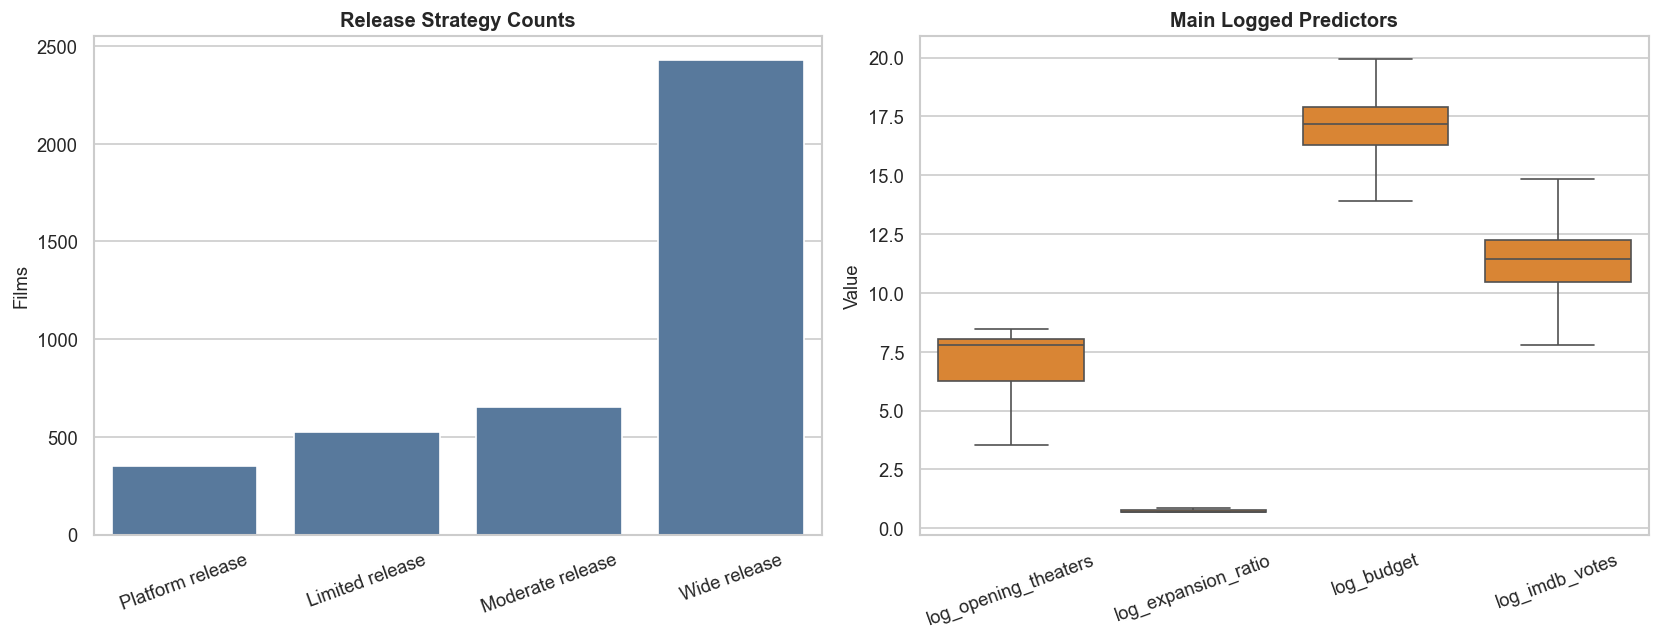

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

strategy_order = ["Platform release", "Limited release", "Moderate release", "Wide release"]
sns.barplot(data=strategy_summary, x="release_strategy", y="films", order=strategy_order, color="#4C78A8", ax=axes[0])
axes[0].set_title("Release Strategy Counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("Films")
axes[0].tick_params(axis="x", rotation=20)

plot_vars = ["log_opening_theaters", "log_expansion_ratio", "log_budget", "log_imdb_votes"]
plot_df = regression_df[plot_vars].melt(var_name="variable", value_name="value")
sns.boxplot(data=plot_df, x="variable", y="value", color="#F58518", showfliers=False, ax=axes[1])
axes[1].set_title("Main Logged Predictors")
axes[1].set_xlabel("")
axes[1].set_ylabel("Value")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
save_figure(fig, "fig_01_regression_variable_distributions", "Release-strategy counts and distributions of the main logged predictors.")
plt.show()


Saved table: figures_analysis/table_05_regression_spearman_correlation.csv
Saved table: figures_analysis/table_05_regression_spearman_correlation.html


,platform_release,limited_release,wide_release,log_opening_theaters,log_expansion_ratio,log_budget,log_imdb_votes,is_franchise,imdb_rating_num,legs,log_worldwide_box_office,roi_worldwide_capped
platform_release,1.0000,0.5990,-0.4020,-0.4270,0.5070,-0.1670,0.0910,-0.1490,0.3100,0.2910,-0.0390,0.1240
limited_release,0.5990,1.0000,-0.6710,-0.7190,0.6300,-0.4770,-0.1810,-0.2700,0.3130,0.4370,-0.4300,-0.0930
wide_release,-0.4020,-0.6710,1.0000,0.8430,-0.5280,0.5860,0.2790,0.2710,-0.2800,-0.3550,0.5390,0.1310
log_opening_theaters,-0.4270,-0.7190,0.8430,1.0000,-0.5540,0.7000,0.3870,0.4120,-0.2200,-0.3440,0.6840,0.2040
log_expansion_ratio,0.5070,0.6300,-0.5280,-0.5540,1.0000,-0.3080,0.0570,-0.1410,0.4110,0.6050,-0.1010,0.1860
log_budget,-0.1670,-0.4770,0.5860,0.7000,-0.3080,1.0000,0.4820,0.2760,-0.0230,-0.1350,0.7130,-0.0680
log_imdb_votes,0.0910,-0.1810,0.2790,0.3870,0.0570,0.4820,1.0000,0.3250,0.4740,0.1880,0.7090,0.4610
is_franchise,-0.1490,-0.2700,0.2710,0.4120,-0.1410,0.2760,0.3250,1.0000,-0.0220,-0.0590,0.4810,0.3700
imdb_rating_num,0.3100,0.3130,-0.2800,-0.2200,0.4110,-0.0230,0.4740,-0.0220,1.0000,0.5140,0.1710,0.2850
legs,0.2910,0.4370,-0.3550,-0.3440,0.6050,-0.1350,0.1880,-0.0590,0.5140,1.0000,0.1170,0.3150


Saved figure: figures_analysis/fig_02_regression_correlation_heatmap.png


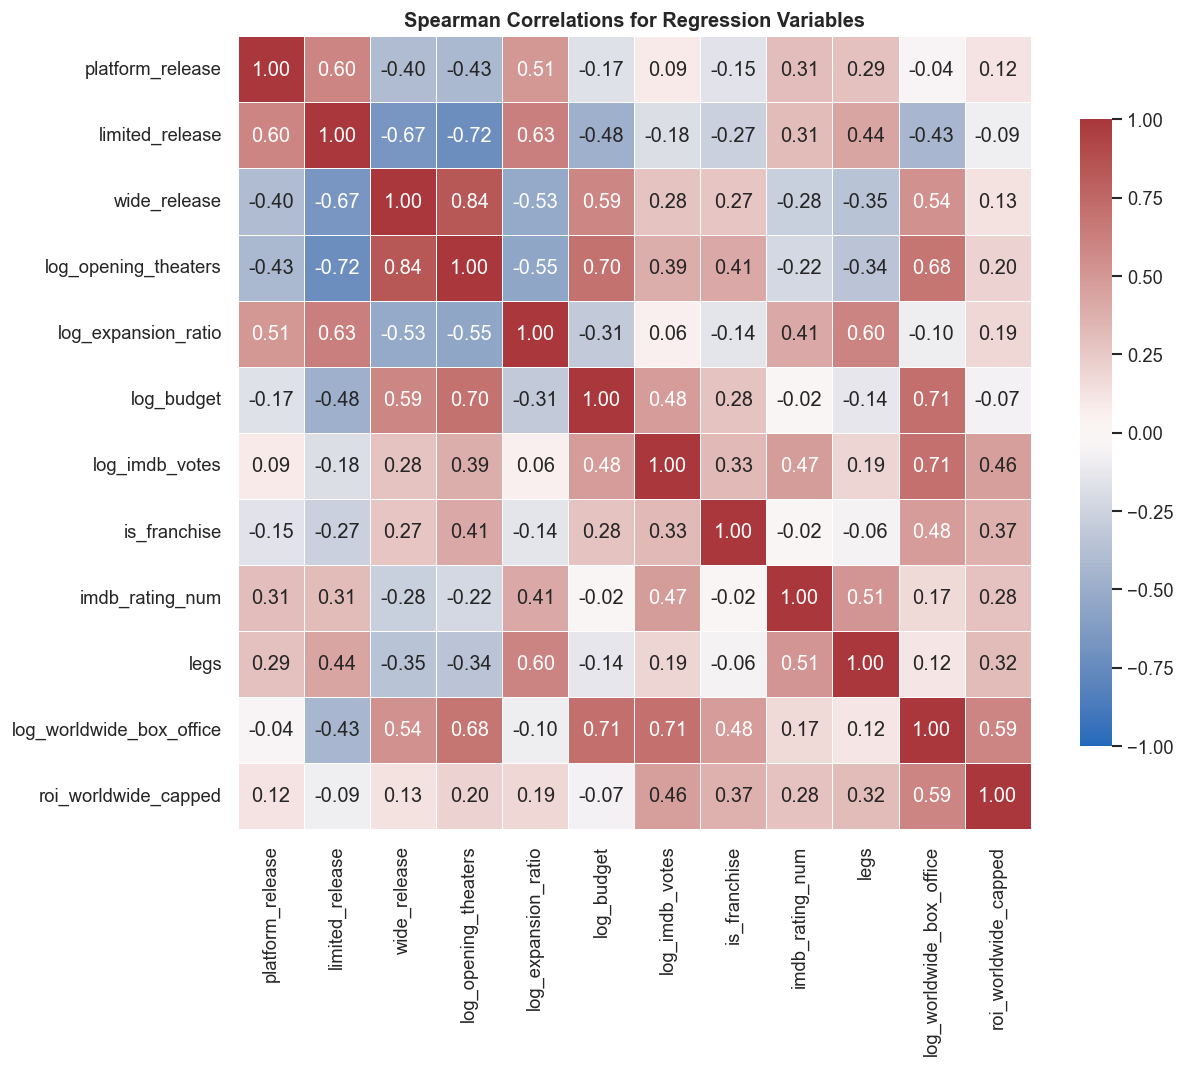

In [6]:
corr_vars = [
    "platform_release", "limited_release", "wide_release", "log_opening_theaters",
    "log_expansion_ratio", "log_budget", "log_imdb_votes", "is_franchise",
    "imdb_rating_num", "legs", "log_worldwide_box_office", "roi_worldwide_capped",
]

corr_matrix = regression_df[corr_vars].corr(method="spearman").round(3)
corr_table = corr_matrix.reset_index().rename(columns={"index": "variable"})
save_table(corr_table, "table_05_regression_spearman_correlation", "Spearman correlation matrix for regression variables.")
display(corr_matrix)

fig, ax = plt.subplots(figsize=(10.5, 9))
sns.heatmap(corr_matrix, cmap="vlag", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", linewidths=.5, square=True, cbar_kws={"shrink": .75}, ax=ax)
ax.set_title("Spearman Correlations for Regression Variables")
plt.tight_layout()
save_figure(fig, "fig_02_regression_correlation_heatmap", "Correlation heatmap for the main regression variables.")
plt.show()


In [7]:
# VIF is calculated on the core numeric predictors, not on the large set of fixed-effect dummies.
vif_vars = [
    "platform_release", "log_opening_theaters", "log_expansion_ratio",
    "log_budget", "log_imdb_votes", "is_franchise", "imdb_rating_num",
]
vif_data = regression_df[vif_vars].dropna().copy()
X_vif = sm.add_constant(vif_data)
vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "vif": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).query("variable != 'const'").round(3)

save_table(vif_table, "table_06_core_predictor_vif", "Variance inflation factors for the core non-fixed-effect predictors.")
display(vif_table)


Saved table: figures_analysis/table_06_core_predictor_vif.csv
Saved table: figures_analysis/table_06_core_predictor_vif.html


,variable,vif
1,platform_release,3.8870
2,log_opening_theaters,6.5590
3,log_expansion_ratio,9.7520
4,log_budget,1.8460
5,log_imdb_votes,1.5150
6,is_franchise,1.1490
7,imdb_rating_num,1.3170


**Diagnostic commentary.** The multicollinearity check is meant to identify whether scarcity variables are too redundant to interpret together. Some correlation is expected because platform release, opening scale, and expansion are all derived from theater counts. The thesis interpretation should therefore focus on broad patterns across models rather than treating any single coefficient as a causal mechanism.


## 3. Model Specifications

All OLS models use HC3 robust standard errors. This is important because film revenue, ROI, and theater counts are skewed and likely heteroskedastic. The binary platform-release model is estimated as a binomial GLM because the full fixed-effect `Logit` specification is singular with this dataset; the interpretation remains logistic, and the notebook reports odds ratios.


In [8]:
model_specs = pd.DataFrame([
    ["M1", "IMDb rating", "imdb_rating_num", "OLS HC3", "Does platform scarcity predict perceived value after controls?"],
    ["M2", "Legs", "legs", "OLS HC3", "Does platform scarcity predict sustained theatrical demand?"],
    ["M3", "Worldwide box office", "log_worldwide_box_office", "OLS HC3", "Does scarcity constrain or support commercial scale after controls?"],
    ["M4", "Worldwide ROI", "roi_worldwide_capped", "OLS HC3", "Is scarcity commercially efficient relative to budget?"],
    ["M5", "Franchise interaction", "imdb_rating_num", "OLS HC3", "Does opening scale mean something different for franchise films?"],
    ["M6", "Quality interaction", "log_worldwide_box_office", "OLS HC3", "Does platform scarcity work better when rating is high?"],
    ["M7", "Platform-release likelihood", "platform_release", "Binomial GLM HC3", "Which films are more likely to receive platform-release treatment?"],
    ["M8", "Box-office quantiles", "log_worldwide_box_office", "Quantile regression", "Does scarcity matter differently across the box-office distribution?"],
])
model_specs.columns = ["model", "short_name", "dependent_variable", "estimator", "thesis_purpose"]
save_table(model_specs, "table_07_model_specifications", "Regression model specifications and thesis purpose.")
display(model_specs)


Saved table: figures_analysis/table_07_model_specifications.csv
Saved table: figures_analysis/table_07_model_specifications.html


,model,short_name,dependent_variable,estimator,thesis_purpose
0,M1,IMDb rating,imdb_rating_num,OLS HC3,Does platform scarcity predict perceived value...
1,M2,Legs,legs,OLS HC3,Does platform scarcity predict sustained theat...
2,M3,Worldwide box office,log_worldwide_box_office,OLS HC3,Does scarcity constrain or support commercial ...
3,M4,Worldwide ROI,roi_worldwide_capped,OLS HC3,Is scarcity commercially efficient relative to...
4,M5,Franchise interaction,imdb_rating_num,OLS HC3,Does opening scale mean something different fo...
5,M6,Quality interaction,log_worldwide_box_office,OLS HC3,Does platform scarcity work better when rating...
6,M7,Platform-release likelihood,platform_release,Binomial GLM HC3,Which films are more likely to receive platfor...
7,M8,Box-office quantiles,log_worldwide_box_office,Quantile regression,Does scarcity matter differently across the bo...


In [9]:
formulas = {
    "M1_perceived_value": """
        imdb_rating_num ~ platform_release
                        + log_opening_theaters
                        + log_expansion_ratio
                        + log_budget
                        + log_imdb_votes
                        + is_franchise
                        + C(genre_fe)
                        + C(source_fe)
                        + C(creative_type_fe)
                        + C(release_year)
    """,
    "M2_legs": """
        legs ~ platform_release
             + log_opening_theaters
             + log_expansion_ratio
             + imdb_rating_num
             + log_budget
             + is_franchise
             + C(genre_fe)
             + C(release_year)
    """,
    "M3_box_office": """
        log_worldwide_box_office ~ platform_release
                                 + log_opening_theaters
                                 + log_expansion_ratio
                                 + imdb_rating_num
                                 + log_budget
                                 + is_franchise
                                 + C(genre_fe)
                                 + C(source_fe)
                                 + C(release_year)
    """,
    "M4_roi": """
        roi_worldwide_capped ~ platform_release
                             + log_opening_theaters
                             + log_expansion_ratio
                             + imdb_rating_num
                             + log_budget
                             + is_franchise
                             + C(genre_fe)
                             + C(release_year)
    """,
    "M5_franchise_interaction": """
        imdb_rating_num ~ log_opening_theaters * is_franchise
                        + log_budget
                        + log_imdb_votes
                        + C(genre_fe)
                        + C(release_year)
    """,
    "M6_quality_interaction": """
        log_worldwide_box_office ~ platform_release * high_rating
                                 + log_opening_theaters
                                 + log_expansion_ratio
                                 + log_budget
                                 + is_franchise
                                 + C(genre_fe)
                                 + C(release_year)
    """,
    "M7_platform_glm": """
        platform_release ~ imdb_rating_num
                         + log_budget
                         + is_franchise
                         + C(genre_fe)
                         + C(source_fe)
                         + C(release_decade)
    """,
    "M8_quantile_box_office": """
        log_worldwide_box_office ~ platform_release
                                 + log_opening_theaters
                                 + log_expansion_ratio
                                 + imdb_rating_num
                                 + log_budget
                                 + is_franchise
    """,
}

models = {}
models["M1_perceived_value"] = smf.ols(formulas["M1_perceived_value"], data=regression_df).fit(cov_type="HC3")
models["M2_legs"] = smf.ols(formulas["M2_legs"], data=regression_df).fit(cov_type="HC3")
models["M3_box_office"] = smf.ols(formulas["M3_box_office"], data=regression_df).fit(cov_type="HC3")
models["M4_roi"] = smf.ols(formulas["M4_roi"], data=regression_df).fit(cov_type="HC3")
models["M5_franchise_interaction"] = smf.ols(formulas["M5_franchise_interaction"], data=regression_df).fit(cov_type="HC3")
models["M6_quality_interaction"] = smf.ols(formulas["M6_quality_interaction"], data=regression_df).fit(cov_type="HC3")
models["M7_platform_glm"] = smf.glm(formulas["M7_platform_glm"], data=regression_df, family=sm.families.Binomial()).fit(cov_type="HC3")

quantile_model = smf.quantreg(formulas["M8_quantile_box_office"], data=regression_df)
quantile_results = {q: quantile_model.fit(q=q, max_iter=2000) for q in [0.25, 0.50, 0.75, 0.90]}

print("Fitted models:")
for name, result in models.items():
    print(f"{name}: n={int(result.nobs):,}")
for q, result in quantile_results.items():
    print(f"M8 quantile {q}: n={int(result.nobs):,}")


Fitted models:
M1_perceived_value: n=3,861
M2_legs: n=3,861
M3_box_office: n=3,861
M4_roi: n=3,861
M5_franchise_interaction: n=3,861
M6_quality_interaction: n=3,861
M7_platform_glm: n=3,861
M8 quantile 0.25: n=3,861
M8 quantile 0.5: n=3,861
M8 quantile 0.75: n=3,861
M8 quantile 0.9: n=3,861


## 4. Main Regression Results

The table below extracts the theoretically important coefficients from each model. The full fixed-effect summaries are saved separately as a text file because they are too large for a thesis-facing table.


In [10]:
terms_of_interest = [
    "platform_release", "log_opening_theaters", "log_expansion_ratio",
    "log_budget", "log_imdb_votes", "imdb_rating_num", "is_franchise",
    "high_rating", "platform_release:high_rating", "log_opening_theaters:is_franchise",
]

model_labels = {
    "M1_perceived_value": "M1 IMDb rating",
    "M2_legs": "M2 Legs",
    "M3_box_office": "M3 Worldwide box office",
    "M4_roi": "M4 ROI",
    "M5_franchise_interaction": "M5 Franchise interaction",
    "M6_quality_interaction": "M6 Quality interaction",
    "M7_platform_glm": "M7 Platform likelihood",
}

def tidy_result(result, model_name, terms=None):
    conf = result.conf_int()
    rows = []
    for term in result.params.index:
        if terms is not None and term not in terms:
            continue
        rows.append({
            "model": model_name,
            "term": term,
            "coef": result.params[term],
            "std_error": result.bse[term],
            "p_value": result.pvalues[term],
            "ci_low": conf.loc[term, 0],
            "ci_high": conf.loc[term, 1],
            "stars": p_stars(result.pvalues[term]),
        })
    return pd.DataFrame(rows)

key_results = pd.concat(
    [tidy_result(result, model_labels[name], terms_of_interest) for name, result in models.items()],
    ignore_index=True,
).round(4)

all_results = pd.concat(
    [tidy_result(result, model_labels[name], terms=None) for name, result in models.items()],
    ignore_index=True,
).round(6)

model_fit = []
for name, result in models.items():
    row = {
        "model": model_labels[name],
        "nobs": int(result.nobs),
        "df_model": float(result.df_model),
        "estimator": "Binomial GLM" if name == "M7_platform_glm" else "OLS",
    }
    if hasattr(result, "rsquared"):
        row["r_squared"] = result.rsquared
        row["adj_r_squared"] = result.rsquared_adj
    else:
        row["r_squared"] = np.nan
        row["adj_r_squared"] = np.nan
        row["pseudo_r2_cs"] = result.pseudo_rsquared(kind="cs")
    model_fit.append(row)
model_fit = pd.DataFrame(model_fit).round(4)

save_table(key_results, "table_08_key_regression_terms", "Key theoretically relevant coefficients from the main regression models.")
save_table(all_results, "table_09_all_regression_coefficients", "All coefficients from the main regression models, including fixed effects.")
save_table(model_fit, "table_10_model_fit_summary", "Sample sizes and fit statistics for the main regression models.")

display(key_results)
display(model_fit)


Saved table: figures_analysis/table_08_key_regression_terms.csv
Saved table: figures_analysis/table_08_key_regression_terms.html
Saved table: figures_analysis/table_09_all_regression_coefficients.csv
Saved table: figures_analysis/table_09_all_regression_coefficients.html
Saved table: figures_analysis/table_10_model_fit_summary.csv
Saved table: figures_analysis/table_10_model_fit_summary.html


,model,term,coef,std_error,p_value,ci_low,ci_high,stars
0,M1 IMDb rating,platform_release,0.0858,0.0764,0.2615,-0.0640,0.2355,
1,M1 IMDb rating,log_opening_theaters,-0.0884,0.0180,0.0000,-0.1237,-0.0530,***
2,M1 IMDb rating,log_expansion_ratio,0.0313,0.0305,0.3037,-0.0284,0.0910,
3,M1 IMDb rating,log_budget,0.0043,0.0186,0.8161,-0.0322,0.0408,
4,M1 IMDb rating,log_imdb_votes,0.1998,0.0194,0.0000,0.1619,0.2378,***
5,M1 IMDb rating,is_franchise,0.0796,0.0379,0.0357,0.0053,0.1539,*
6,M2 Legs,platform_release,-2.3034,1.0864,0.0340,-4.4327,-0.1742,*
7,M2 Legs,log_opening_theaters,-0.5390,0.1187,0.0000,-0.7717,-0.3063,***
8,M2 Legs,log_expansion_ratio,0.5091,0.2741,0.0632,-0.0281,1.0463,+
9,M2 Legs,imdb_rating_num,0.7837,0.0886,0.0000,0.6100,0.9574,***


,model,nobs,df_model,estimator,r_squared,adj_r_squared,pseudo_r2_cs
0,M1 IMDb rating,3861,89.0000,OLS,0.3525,0.3372,NaN
1,M2 Legs,3861,69.0000,OLS,0.3947,0.3836,NaN
2,M3 Worldwide box office,3861,81.0000,OLS,0.7689,0.7640,NaN
3,M4 ROI,3861,69.0000,OLS,0.4074,0.3966,NaN
4,M5 Franchise interaction,3861,68.0000,OLS,0.3306,0.3186,NaN
5,M6 Quality interaction,3861,70.0000,OLS,0.7529,0.7483,NaN
6,M7 Platform likelihood,3861,31.0000,Binomial GLM,NaN,NaN,0.1557


In [11]:
summary_text_parts = []
for name, result in models.items():
    summary_text_parts.append("=" * 90)
    summary_text_parts.append(model_labels[name])
    summary_text_parts.append("=" * 90)
    summary_text_parts.append(str(result.summary()))
    summary_text_parts.append("")
for q, result in quantile_results.items():
    summary_text_parts.append("=" * 90)
    summary_text_parts.append(f"M8 Quantile regression q={q}")
    summary_text_parts.append("=" * 90)
    summary_text_parts.append(str(result.summary()))
    summary_text_parts.append("")

save_text("\n".join(summary_text_parts), "regression_results", "Full statsmodels summaries for all OLS, GLM, and quantile models.")


Saved text: figures_analysis/regression_results.txt


PosixPath('/Users/alexisgod/Desktop/movie_scarcity/figures_analysis/regression_results.txt')

Saved figure: figures_analysis/fig_03_key_scarcity_coefficients.png


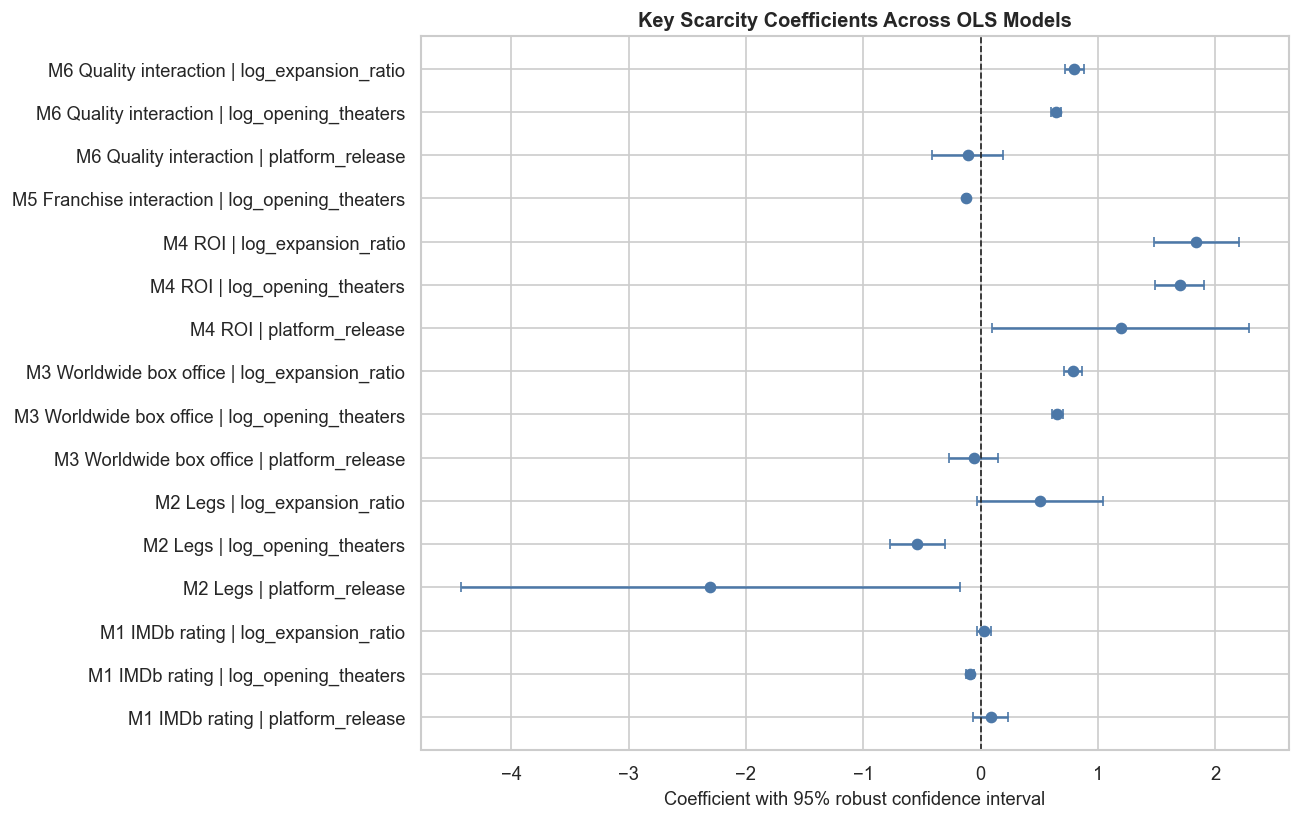

In [12]:
plot_terms = ["platform_release", "log_opening_theaters", "log_expansion_ratio"]
coef_plot = key_results[key_results["term"].isin(plot_terms)].copy()
coef_plot = coef_plot[coef_plot["model"] != "M7 Platform likelihood"]

fig, ax = plt.subplots(figsize=(11, 7))
y_labels = []
y_pos = []
for i, (_, row) in enumerate(coef_plot.iterrows()):
    y_labels.append(f"{row['model']} | {row['term']}")
    y_pos.append(i)
    ax.errorbar(
        row["coef"], i,
        xerr=[[row["coef"] - row["ci_low"]], [row["ci_high"] - row["coef"]]],
        fmt="o", color="#4C78A8", ecolor="#4C78A8", capsize=3,
    )
ax.axvline(0, color="#222222", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_title("Key Scarcity Coefficients Across OLS Models")
ax.set_xlabel("Coefficient with 95% robust confidence interval")
ax.set_ylabel("")
plt.tight_layout()
save_figure(fig, "fig_03_key_scarcity_coefficients", "Coefficient plot for platform release, opening scale, and expansion terms across OLS models.")
plt.show()


### Model 1 Commentary: Scarcity and Perceived Value

Model 1 is the closest quantitative test of the central thesis claim. A positive `platform_release` coefficient or a negative `log_opening_theaters` coefficient would be consistent with the idea that restricted initial access is associated with higher perceived value. This still does not prove that scarcity creates value; it shows whether a scarcity pattern is systematically associated with IMDb rating after controls.


In [13]:
m1_terms = key_results.query("model == 'M1 IMDb rating'").copy()
display(m1_terms)


,model,term,coef,std_error,p_value,ci_low,ci_high,stars
0,M1 IMDb rating,platform_release,0.0858,0.0764,0.2615,-0.0640,0.2355,
1,M1 IMDb rating,log_opening_theaters,-0.0884,0.0180,0.0000,-0.1237,-0.0530,***
2,M1 IMDb rating,log_expansion_ratio,0.0313,0.0305,0.3037,-0.0284,0.0910,
3,M1 IMDb rating,log_budget,0.0043,0.0186,0.8161,-0.0322,0.0408,
4,M1 IMDb rating,log_imdb_votes,0.1998,0.0194,0.0000,0.1619,0.2378,***
5,M1 IMDb rating,is_franchise,0.0796,0.0379,0.0357,0.0053,0.1539,*


### Model 2 Commentary: Scarcity and Legs

Model 2 asks whether platform scarcity is associated with sustained demand beyond opening weekend. This is relevant because symbolic scarcity should not only restrict access; it should be paired with later demand, word of mouth, prestige accumulation, or urgency.


In [14]:
m2_terms = key_results.query("model == 'M2 Legs'").copy()
display(m2_terms)


,model,term,coef,std_error,p_value,ci_low,ci_high,stars
6,M2 Legs,platform_release,-2.3034,1.0864,0.0340,-4.4327,-0.1742,*
7,M2 Legs,log_opening_theaters,-0.5390,0.1187,0.0000,-0.7717,-0.3063,***
8,M2 Legs,log_expansion_ratio,0.5091,0.2741,0.0632,-0.0281,1.0463,+
9,M2 Legs,imdb_rating_num,0.7837,0.0886,0.0000,0.6100,0.9574,***
10,M2 Legs,log_budget,0.0576,0.1122,0.6078,-0.1623,0.2775,
11,M2 Legs,is_franchise,0.2432,0.1700,0.1526,-0.0900,0.5764,


### Models 3 and 4 Commentary: Commercial Scale Versus Efficiency

Model 3 treats scarcity as a possible access constraint: broad initial availability should usually help worldwide box office. Model 4 asks a different question: whether platform scarcity is commercially efficient relative to budget. This distinction matters because scarcity can reduce scale while still supporting value-building or ROI.


In [15]:
display(key_results[key_results["model"].isin(["M3 Worldwide box office", "M4 ROI"])])


,model,term,coef,std_error,p_value,ci_low,ci_high,stars
12,M3 Worldwide box office,platform_release,-0.0587,0.1064,0.5811,-0.2674,0.1499,
13,M3 Worldwide box office,log_opening_theaters,0.6535,0.0227,0.0000,0.6089,0.6981,***
14,M3 Worldwide box office,log_expansion_ratio,0.7875,0.0411,0.0000,0.7069,0.8681,***
15,M3 Worldwide box office,imdb_rating_num,0.4139,0.0192,0.0000,0.3763,0.4515,***
16,M3 Worldwide box office,log_budget,0.4135,0.0197,0.0000,0.3750,0.4520,***
17,M3 Worldwide box office,is_franchise,0.7384,0.0324,0.0000,0.6748,0.8020,***
18,M4 ROI,platform_release,1.1925,0.5601,0.0333,0.0947,2.2903,*
19,M4 ROI,log_opening_theaters,1.6963,0.1080,0.0000,1.4847,1.9079,***
20,M4 ROI,log_expansion_ratio,1.8375,0.1852,0.0000,1.4745,2.2006,***
21,M4 ROI,imdb_rating_num,1.2303,0.0919,0.0000,1.0502,1.4104,***


## 5. Interaction Models

The interaction models test the thesis idea that scarcity does not work the same way for every film. Franchise films may carry mainstream event meanings, while platform releases may work best when paired with quality or legitimacy signals.


Saved figure: figures_analysis/fig_04_predicted_rating_franchise_interaction.png


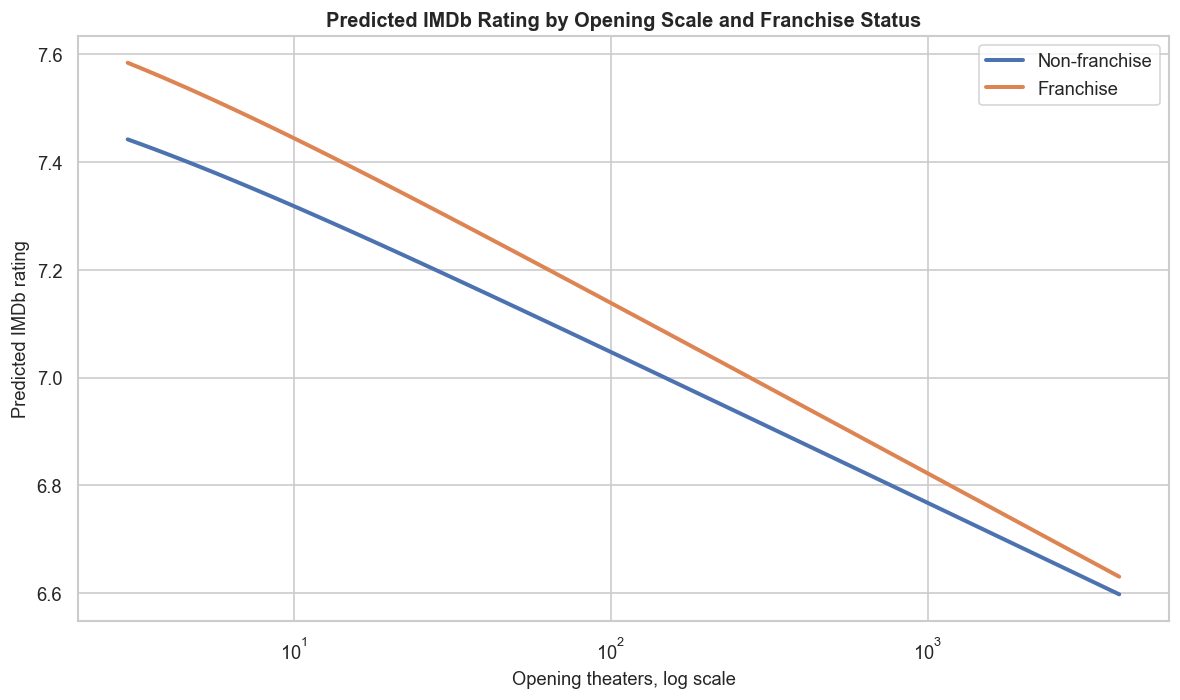

Saved table: figures_analysis/table_11_franchise_interaction_predictions.csv
Saved table: figures_analysis/table_11_franchise_interaction_predictions.html


,log_budget,log_imdb_votes,genre_fe,release_year,log_opening_theaters,is_franchise,predicted_imdb_rating,franchise_label,opening_theaters_approx
0,17.1828,11.4449,Drama,2009,1.3863,0,7.4424,Non-franchise,3.0000
1,17.1828,11.4449,Drama,2009,1.4561,0,7.4338,Non-franchise,3.2892
2,17.1828,11.4449,Drama,2009,1.5259,0,7.4253,Non-franchise,3.5992
3,17.1828,11.4449,Drama,2009,1.5957,0,7.4168,Non-franchise,3.9317
4,17.1828,11.4449,Drama,2009,1.6655,0,7.4082,Non-franchise,4.2882
...,...,...,...,...,...,...,...,...,...
195,17.1828,11.4449,Drama,2009,8.0169,1,6.6688,Franchise,"3,030.6603"
196,17.1828,11.4449,Drama,2009,8.0867,1,6.6591,Franchise,"3,249.8155"
197,17.1828,11.4449,Drama,2009,8.1565,1,6.6495,Franchise,"3,484.8133"
198,17.1828,11.4449,Drama,2009,8.2263,1,6.6398,Franchise,"3,736.7988"


In [16]:
# Predicted IMDb rating across opening scale for franchise and non-franchise films.
pred_base = {
    "log_budget": regression_df["log_budget"].median(),
    "log_imdb_votes": regression_df["log_imdb_votes"].median(),
    "genre_fe": regression_df["genre_fe"].mode().iloc[0],
    "release_year": int(regression_df["release_year"].median()),
}
opening_grid = np.linspace(regression_df["log_opening_theaters"].quantile(.05), regression_df["log_opening_theaters"].quantile(.95), 100)
pred_rows = []
for franchise in [0, 1]:
    for value in opening_grid:
        row = pred_base.copy()
        row["log_opening_theaters"] = value
        row["is_franchise"] = franchise
        pred_rows.append(row)
pred_interaction = pd.DataFrame(pred_rows)
pred_interaction["predicted_imdb_rating"] = models["M5_franchise_interaction"].predict(pred_interaction)
pred_interaction["franchise_label"] = np.where(pred_interaction["is_franchise"] == 1, "Franchise", "Non-franchise")
pred_interaction["opening_theaters_approx"] = np.expm1(pred_interaction["log_opening_theaters"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=pred_interaction, x="opening_theaters_approx", y="predicted_imdb_rating", hue="franchise_label", linewidth=2.4, ax=ax)
ax.set_xscale("log")
ax.set_title("Predicted IMDb Rating by Opening Scale and Franchise Status")
ax.set_xlabel("Opening theaters, log scale")
ax.set_ylabel("Predicted IMDb rating")
ax.legend(title="")
plt.tight_layout()
save_figure(fig, "fig_04_predicted_rating_franchise_interaction", "Predicted IMDb rating by opening scale for franchise and non-franchise films.")
plt.show()

save_table(pred_interaction, "table_11_franchise_interaction_predictions", "Prediction grid for Model 5 franchise interaction plot.")


Saved figure: figures_analysis/fig_05_quality_interaction_predictions.png


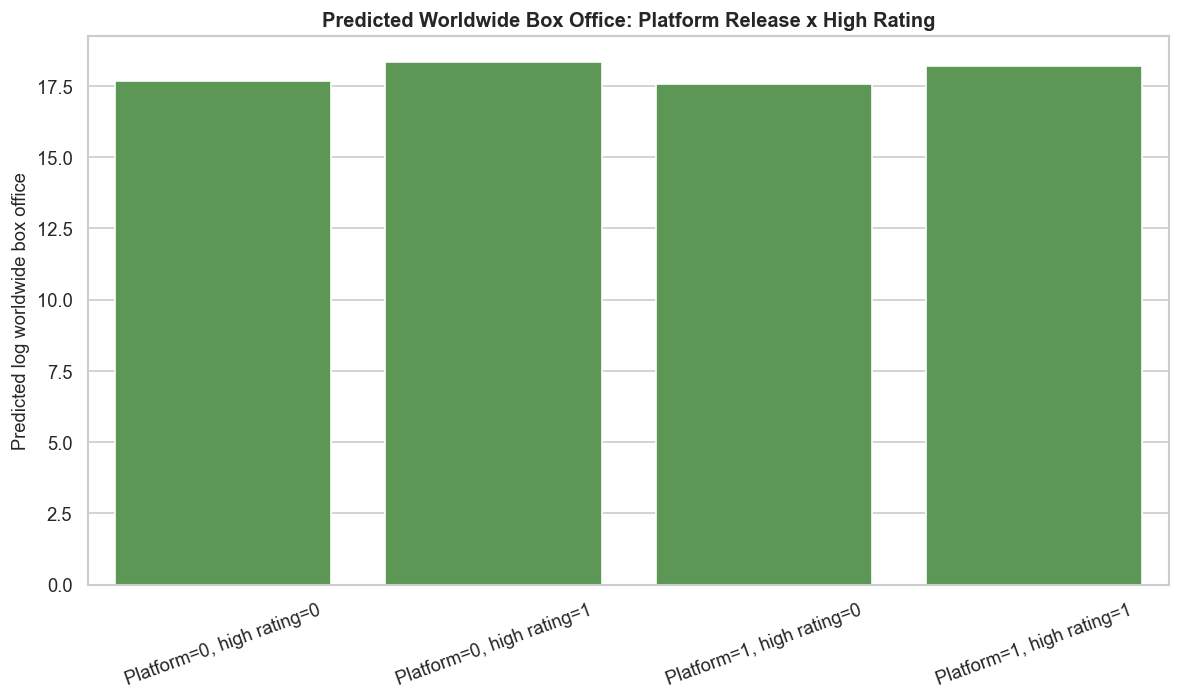

Saved table: figures_analysis/table_12_quality_interaction_predictions.csv
Saved table: figures_analysis/table_12_quality_interaction_predictions.html


,log_opening_theaters,log_expansion_ratio,log_budget,is_franchise,genre_fe,release_year,platform_release,high_rating,group,predicted_log_worldwide_box_office,predicted_worldwide_box_office_usd
0,7.8022,0.6954,17.1828,0,Drama,2009,0,0,"Platform=0, high rating=0",17.6553,"46,514,988.1637"
1,7.8022,0.6954,17.1828,0,Drama,2009,0,1,"Platform=0, high rating=1",18.3205,"90,466,340.4335"
2,7.8022,0.6954,17.1828,0,Drama,2009,1,0,"Platform=1, high rating=0",17.5443,"41,630,752.0407"
3,7.8022,0.6954,17.1828,0,Drama,2009,1,1,"Platform=1, high rating=1",18.1939,"79,711,262.7555"


In [17]:
# Predicted worldwide box-office scale for platform/high-rating combinations.
quality_base = {
    "log_opening_theaters": regression_df["log_opening_theaters"].median(),
    "log_expansion_ratio": regression_df["log_expansion_ratio"].median(),
    "log_budget": regression_df["log_budget"].median(),
    "is_franchise": 0,
    "genre_fe": regression_df["genre_fe"].mode().iloc[0],
    "release_year": int(regression_df["release_year"].median()),
}
quality_rows = []
for platform in [0, 1]:
    for high in [0, 1]:
        row = quality_base.copy()
        row["platform_release"] = platform
        row["high_rating"] = high
        row["group"] = f"Platform={platform}, high rating={high}"
        quality_rows.append(row)
quality_pred = pd.DataFrame(quality_rows)
quality_pred["predicted_log_worldwide_box_office"] = models["M6_quality_interaction"].predict(quality_pred)
quality_pred["predicted_worldwide_box_office_usd"] = np.expm1(quality_pred["predicted_log_worldwide_box_office"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=quality_pred, x="group", y="predicted_log_worldwide_box_office", color="#54A24B", ax=ax)
ax.set_title("Predicted Worldwide Box Office: Platform Release x High Rating")
ax.set_xlabel("")
ax.set_ylabel("Predicted log worldwide box office")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
save_figure(fig, "fig_05_quality_interaction_predictions", "Predicted worldwide box office for platform-release and high-rating combinations.")
plt.show()

save_table(quality_pred.round(4), "table_12_quality_interaction_predictions", "Prediction table for Model 6 platform-release by high-rating interaction.")
display(quality_pred.round(4))


**Interaction commentary.** The franchise interaction is directly connected to the thesis contrast between prestige scarcity and mainstream event cinema. The quality interaction asks whether scarcity works only when paired with perceived legitimacy. If the interaction is positive, it supports the argument that scarcity alone is not enough; it needs quality, prestige, or legitimacy to become value-building.


## 6. Logistic Model: Which Films Receive Platform Scarcity?

The plan proposes a logistic regression predicting platform release. A standard fixed-effect `Logit` specification is singular in this dataset because rare categories and years can perfectly predict the platform-release outcome. The notebook therefore estimates the same kind of binary model with a binomial GLM and collapsed time categories. Coefficients are converted to odds ratios for interpretation.


Saved table: figures_analysis/table_13_platform_glm_all_odds_ratios.csv
Saved table: figures_analysis/table_13_platform_glm_all_odds_ratios.html
Saved table: figures_analysis/table_14_platform_glm_key_odds_ratios.csv
Saved table: figures_analysis/table_14_platform_glm_key_odds_ratios.html


,model,term,coef,std_error,p_value,ci_low,ci_high,stars,odds_ratio,or_ci_low,or_ci_high
29,M7 Platform likelihood,imdb_rating_num,1.4959,0.1040,0.0000,1.2921,1.6996,***,4.4633,3.6406,5.4720
30,M7 Platform likelihood,log_budget,-0.2116,0.0496,0.0000,-0.3087,-0.1144,***,0.8093,0.7344,0.8919
31,M7 Platform likelihood,is_franchise,-1.1487,0.2581,0.0000,-1.6545,-0.6429,***,0.3171,0.1912,0.5258


Saved figure: figures_analysis/fig_06_platform_release_probability.png


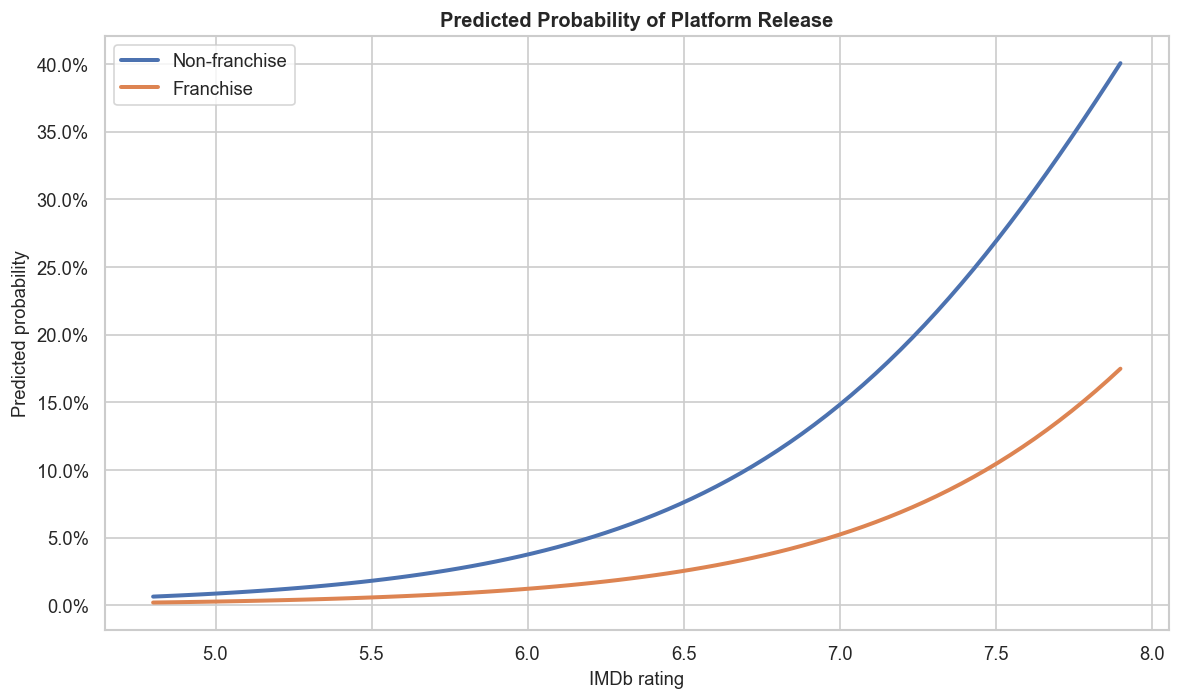

Saved table: figures_analysis/table_15_platform_probability_predictions.csv
Saved table: figures_analysis/table_15_platform_probability_predictions.html


,imdb_rating_num,log_budget,is_franchise,genre_fe,source_fe,release_decade,predicted_platform_probability,franchise_label
0,4.8000,17.1828,0,Drama,Original Screenplay,2010s,0.0064,Non-franchise
1,4.8392,17.1828,0,Drama,Original Screenplay,2010s,0.0068,Non-franchise
2,4.8785,17.1828,0,Drama,Original Screenplay,2010s,0.0072,Non-franchise
3,4.9177,17.1828,0,Drama,Original Screenplay,2010s,0.0077,Non-franchise
4,4.9570,17.1828,0,Drama,Original Screenplay,2010s,0.0081,Non-franchise
...,...,...,...,...,...,...,...,...
155,7.7430,17.1828,1,Drama,Original Screenplay,2010s,0.1435,Franchise
156,7.7823,17.1828,1,Drama,Original Screenplay,2010s,0.1508,Franchise
157,7.8215,17.1828,1,Drama,Original Screenplay,2010s,0.1585,Franchise
158,7.8608,17.1828,1,Drama,Original Screenplay,2010s,0.1665,Franchise


In [18]:
glm_result = models["M7_platform_glm"]
glm_terms = tidy_result(glm_result, "M7 Platform likelihood", terms=None)
glm_terms["odds_ratio"] = np.exp(glm_terms["coef"])
glm_terms["or_ci_low"] = np.exp(glm_terms["ci_low"])
glm_terms["or_ci_high"] = np.exp(glm_terms["ci_high"])

important_glm_terms = ["imdb_rating_num", "log_budget", "is_franchise"]
glm_key = glm_terms[glm_terms["term"].isin(important_glm_terms)].round(4)
save_table(glm_terms.round(6), "table_13_platform_glm_all_odds_ratios", "All binomial GLM platform-release coefficients converted to odds ratios.")
save_table(glm_key, "table_14_platform_glm_key_odds_ratios", "Key odds ratios for the platform-release likelihood model.")
display(glm_key)

# Prediction grid: probability of platform release by rating and budget, split by franchise status.
rating_grid = np.linspace(regression_df["imdb_rating_num"].quantile(.05), regression_df["imdb_rating_num"].quantile(.95), 80)
prob_rows = []
for franchise in [0, 1]:
    for rating in rating_grid:
        prob_rows.append({
            "imdb_rating_num": rating,
            "log_budget": regression_df["log_budget"].median(),
            "is_franchise": franchise,
            "genre_fe": regression_df["genre_fe"].mode().iloc[0],
            "source_fe": regression_df["source_fe"].mode().iloc[0],
            "release_decade": regression_df["release_decade"].mode().iloc[0],
        })
prob_grid = pd.DataFrame(prob_rows)
prob_grid["predicted_platform_probability"] = glm_result.predict(prob_grid)
prob_grid["franchise_label"] = np.where(prob_grid["is_franchise"] == 1, "Franchise", "Non-franchise")

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=prob_grid, x="imdb_rating_num", y="predicted_platform_probability", hue="franchise_label", linewidth=2.4, ax=ax)
ax.set_title("Predicted Probability of Platform Release")
ax.set_xlabel("IMDb rating")
ax.set_ylabel("Predicted probability")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="")
plt.tight_layout()
save_figure(fig, "fig_06_platform_release_probability", "Predicted platform-release probability by IMDb rating and franchise status.")
plt.show()

save_table(prob_grid.round(5), "table_15_platform_probability_predictions", "Prediction grid for platform-release probability plot.")


**Logistic model commentary.** This model frames scarcity as a distribution choice rather than only an outcome. If higher-rated, lower-budget, non-franchise, or prestige-coded films are more likely to be platform releases, that supports the thesis claim that scarcity is structured by film type and market positioning.


## 7. Quantile Regression

Movie outcomes are heavily skewed. Quantile regression checks whether the scarcity variables matter differently for ordinary performers versus higher-performing breakout films.


Saved table: figures_analysis/table_16_quantile_regression_key_terms.csv
Saved table: figures_analysis/table_16_quantile_regression_key_terms.html


,quantile,term,coef,std_error,p_value,ci_low,ci_high,stars
0,0.2500,platform_release,-0.3338,0.1155,0.0039,-0.5603,-0.1074,**
1,0.2500,log_opening_theaters,0.7302,0.0183,0.0000,0.6943,0.7662,***
2,0.2500,log_expansion_ratio,0.9196,0.0380,0.0000,0.8450,0.9941,***
3,0.2500,imdb_rating_num,0.4080,0.0194,0.0000,0.3700,0.4460,***
4,0.2500,log_budget,0.5013,0.0170,0.0000,0.4680,0.5345,***
5,0.2500,is_franchise,0.8914,0.0433,0.0000,0.8065,0.9763,***
6,0.5000,platform_release,-0.0625,0.1009,0.5358,-0.2603,0.1353,
7,0.5000,log_opening_theaters,0.6718,0.0153,0.0000,0.6419,0.7018,***
8,0.5000,log_expansion_ratio,0.7899,0.0310,0.0000,0.7292,0.8506,***
9,0.5000,imdb_rating_num,0.4240,0.0164,0.0000,0.3920,0.4561,***


Saved figure: figures_analysis/fig_07_quantile_regression_scarcity_terms.png


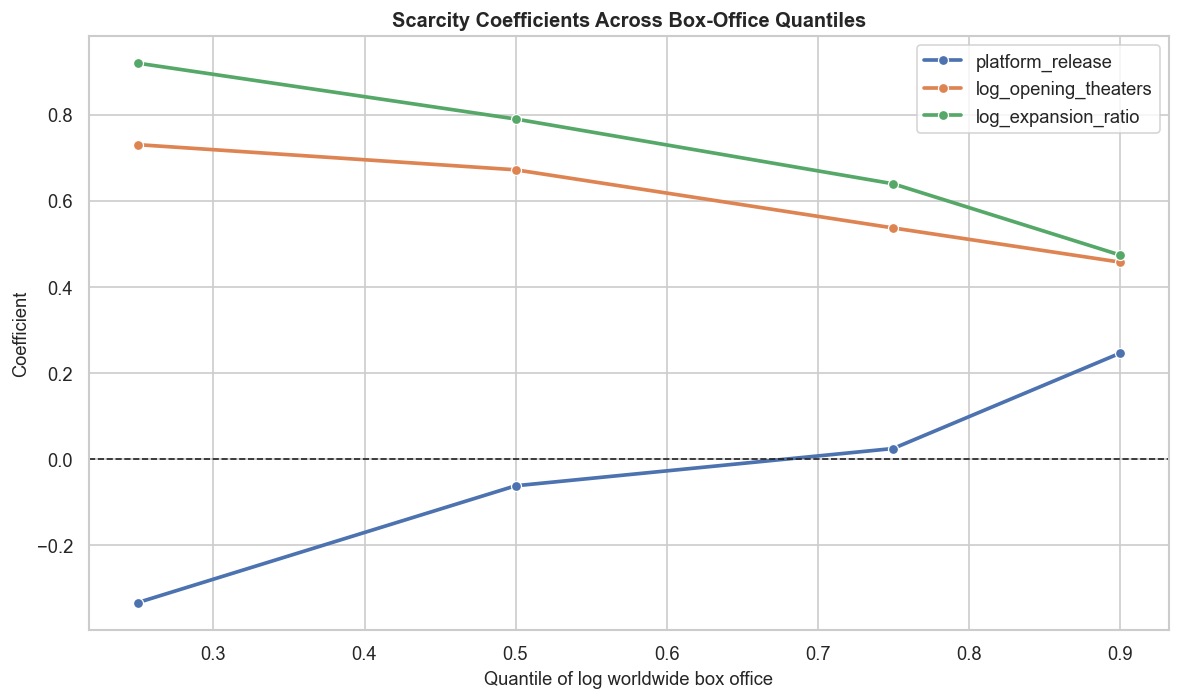

In [19]:
quantile_terms = ["platform_release", "log_opening_theaters", "log_expansion_ratio", "imdb_rating_num", "log_budget", "is_franchise"]
quantile_rows = []
for q, result in quantile_results.items():
    conf = result.conf_int()
    for term in quantile_terms:
        quantile_rows.append({
            "quantile": q,
            "term": term,
            "coef": result.params[term],
            "std_error": result.bse[term],
            "p_value": result.pvalues[term],
            "ci_low": conf.loc[term, 0],
            "ci_high": conf.loc[term, 1],
            "stars": p_stars(result.pvalues[term]),
        })
quantile_table = pd.DataFrame(quantile_rows).round(4)
save_table(quantile_table, "table_16_quantile_regression_key_terms", "Key coefficients from quantile regressions for worldwide box office.")
display(quantile_table)

fig, ax = plt.subplots(figsize=(10, 6))
q_plot = quantile_table[quantile_table["term"].isin(["platform_release", "log_opening_theaters", "log_expansion_ratio"])]
sns.lineplot(data=q_plot, x="quantile", y="coef", hue="term", marker="o", linewidth=2.2, ax=ax)
ax.axhline(0, color="#222222", linestyle="--", linewidth=1)
ax.set_title("Scarcity Coefficients Across Box-Office Quantiles")
ax.set_xlabel("Quantile of log worldwide box office")
ax.set_ylabel("Coefficient")
ax.legend(title="")
plt.tight_layout()
save_figure(fig, "fig_07_quantile_regression_scarcity_terms", "Quantile-regression coefficients for key scarcity terms.")
plt.show()


**Quantile commentary.** If expansion or platform-release coefficients are stronger at higher quantiles, that would suggest scarcity is more relevant for breakout films than for ordinary films. If coefficients are stable or negative, the evidence points more toward scarcity as an access constraint than as a generalized commercial advantage.


## 8. Model Diagnostics and Case Films

This section adds residual diagnostics for the perceived-value model and locates Parasite and Oppenheimer in the regression outputs. These case checks help connect the general models back to the thesis cases.


Saved figure: figures_analysis/fig_08_m1_residual_diagnostics.png


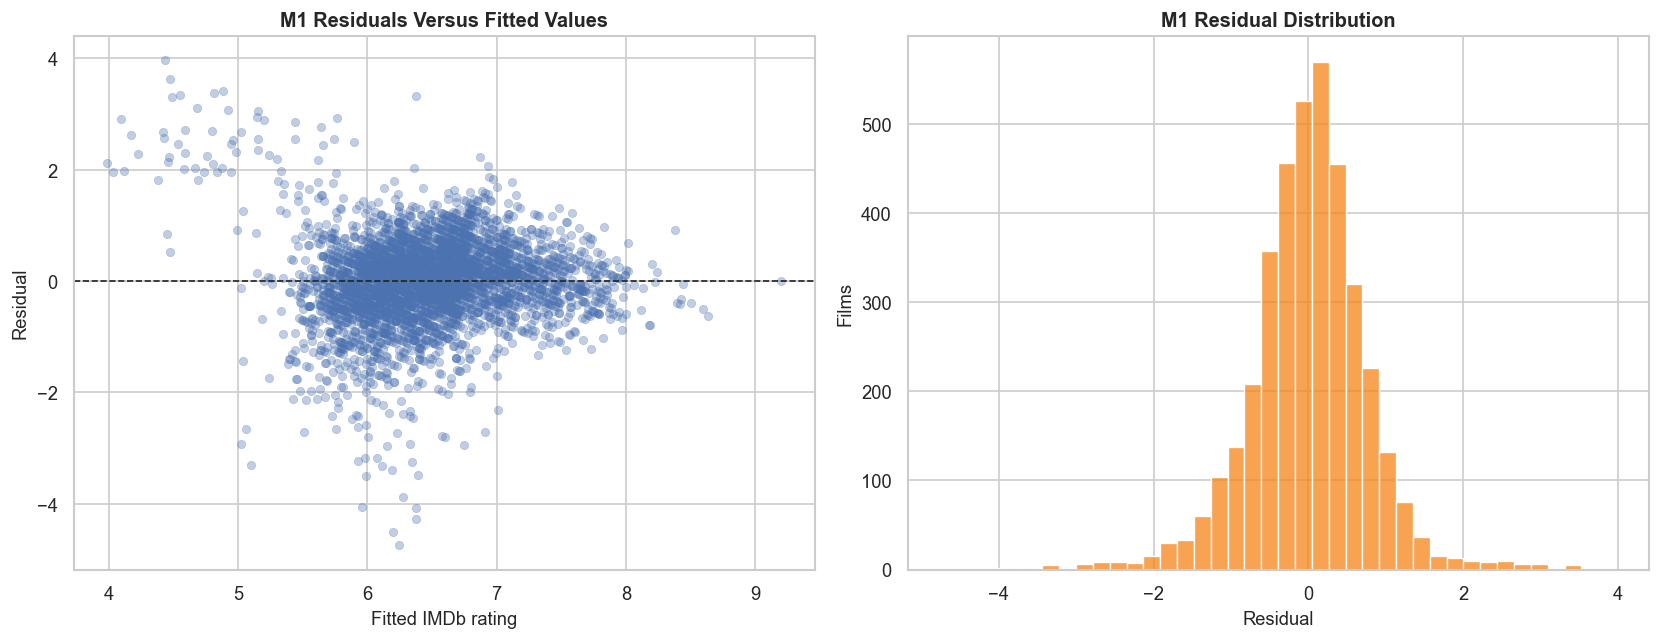

In [20]:
# Residual diagnostics for the core perceived-value model.
m1 = models["M1_perceived_value"]
fitted = pd.Series(m1.fittedvalues, name="fitted")
residuals = pd.Series(m1.resid, name="residual")
diag_df = pd.DataFrame({"fitted_rating": fitted, "residual": residuals})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=diag_df, x="fitted_rating", y="residual", alpha=.35, s=25, edgecolor=None, ax=axes[0])
axes[0].axhline(0, color="#222222", linestyle="--", linewidth=1)
axes[0].set_title("M1 Residuals Versus Fitted Values")
axes[0].set_xlabel("Fitted IMDb rating")
axes[0].set_ylabel("Residual")

sns.histplot(diag_df["residual"], bins=40, color="#F58518", ax=axes[1])
axes[1].set_title("M1 Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Films")

plt.tight_layout()
save_figure(fig, "fig_08_m1_residual_diagnostics", "Residual diagnostics for the perceived-value regression model.")
plt.show()


Saved table: figures_analysis/table_17_case_film_regression_context.csv
Saved table: figures_analysis/table_17_case_film_regression_context.html


,case_label,movie_name,release_year,release_strategy,platform_release,opening_theaters,max_theaters,theater_expansion_ratio,imdb_rating_num,m1_predicted_imdb_rating,m1_rating_residual,legs,roi_worldwide,m4_predicted_roi_capped,m4_roi_residual,worldwide_box_office_usd,m3_predicted_log_worldwide,m3_boxoffice_residual_log
429,Oppenheimer,Oppenheimer,2023,Wide release,0,"3,610.0000","3,761.0000",1.0418,8.2000,7.4958,0.7042,4.0000,9.7652,2.5514,7.2138,"976,518,442.0000",19.0079,1.6916
3032,Parasite,Parasite (기생충),2019,Platform release,1,3.0000,"2,001.0000",667.0000,8.5000,7.7363,0.7637,9.3900,21.4634,7.7736,13.6898,"253,267,858.0000",18.3893,0.9606


Saved figure: figures_analysis/fig_09_case_films_regression_space.png


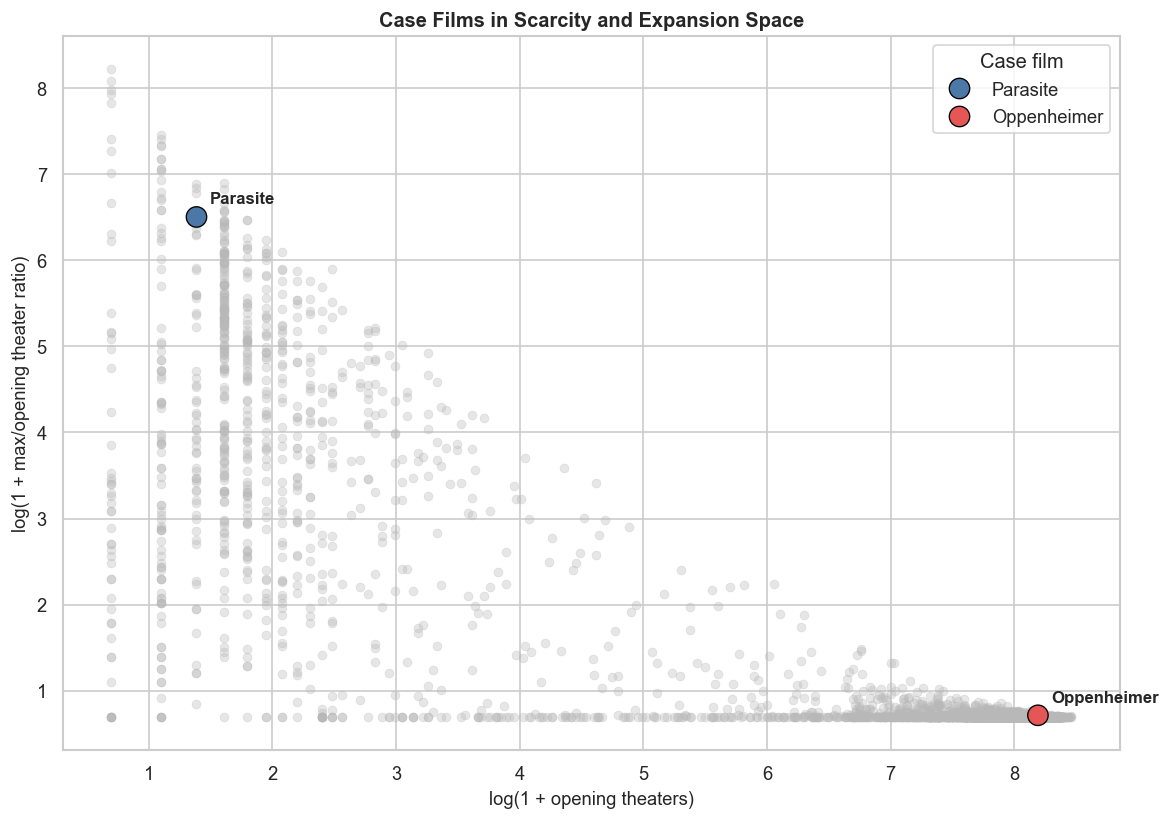

In [21]:
case_mask = regression_df["movie_name"].str.contains("Parasite|Oppenheimer", case=False, na=False, regex=True)
case_films = regression_df.loc[case_mask].copy()
case_films["case_label"] = np.where(case_films["movie_name"].str.contains("Parasite", case=False, na=False), "Parasite", "Oppenheimer")

case_films["m1_predicted_imdb_rating"] = models["M1_perceived_value"].predict(case_films)
case_films["m1_rating_residual"] = case_films["imdb_rating_num"] - case_films["m1_predicted_imdb_rating"]
case_films["m3_predicted_log_worldwide"] = models["M3_box_office"].predict(case_films)
case_films["m3_boxoffice_residual_log"] = case_films["log_worldwide_box_office"] - case_films["m3_predicted_log_worldwide"]
case_films["m4_predicted_roi_capped"] = models["M4_roi"].predict(case_films)
case_films["m4_roi_residual"] = case_films["roi_worldwide_capped"] - case_films["m4_predicted_roi_capped"]

case_cols = [
    "case_label", "movie_name", "release_year", "release_strategy", "platform_release",
    "opening_theaters", "max_theaters", "theater_expansion_ratio", "imdb_rating_num",
    "m1_predicted_imdb_rating", "m1_rating_residual", "legs", "roi_worldwide",
    "m4_predicted_roi_capped", "m4_roi_residual", "worldwide_box_office_usd",
    "m3_predicted_log_worldwide", "m3_boxoffice_residual_log",
]
case_table = case_films[case_cols].round(4)
save_table(case_table, "table_17_case_film_regression_context", "Parasite and Oppenheimer in the regression-variable and model-prediction context.")
display(case_table)

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=regression_df, x="log_opening_theaters", y="log_expansion_ratio", color="#B8B8B8", alpha=.35, s=28, edgecolor=None, ax=ax)
sns.scatterplot(data=case_films, x="log_opening_theaters", y="log_expansion_ratio", hue="case_label", hue_order=["Parasite", "Oppenheimer"], palette={"Parasite": "#4C78A8", "Oppenheimer": "#E45756"}, s=150, edgecolor="black", linewidth=.8, ax=ax)
for _, row in case_films.iterrows():
    ax.annotate(row["case_label"], (row["log_opening_theaters"], row["log_expansion_ratio"]), xytext=(8, 8), textcoords="offset points", fontsize=10, fontweight="bold")
ax.set_title("Case Films in Scarcity and Expansion Space")
ax.set_xlabel("log(1 + opening theaters)")
ax.set_ylabel("log(1 + max/opening theater ratio)")
ax.legend(title="Case film")
plt.tight_layout()
save_figure(fig, "fig_09_case_films_regression_space", "Parasite and Oppenheimer in opening-scarcity and expansion-ratio space.")
plt.show()


**Case-film commentary.** Parasite is a direct match for platform-release scarcity in the regression data because it combines a tiny opening with later expansion. Oppenheimer is not scarce by theater-count measures because it opened wide. Its thesis relevance therefore depends on a different scarcity mechanism: premium-format and temporal scarcity, especially IMAX/70mm access. That mechanism is not directly observed in this CSV and should be handled with case evidence outside the regression.


## 9. Thesis Interpretation and Research-Question Answers

The final table translates the regression evidence back into the thesis questions. The answers are intentionally cautious because the models estimate associations rather than causal effects.


In [22]:
# Pull a few key coefficient signs into a compact interpretation table.
def term_value(model_key, term):
    result = models[model_key]
    if term not in result.params.index:
        return np.nan, np.nan
    return result.params[term], result.pvalues[term]

interpretation_rows = []
for label, model_key, term, question in [
    ("Perceived value", "M1_perceived_value", "platform_release", "Are platform releases associated with IMDb rating?"),
    ("Perceived value", "M1_perceived_value", "log_opening_theaters", "Are wider openings associated with IMDb rating?"),
    ("Sustained demand", "M2_legs", "platform_release", "Are platform releases associated with legs?"),
    ("Commercial scale", "M3_box_office", "log_opening_theaters", "Are wider openings associated with worldwide box office?"),
    ("Commercial efficiency", "M4_roi", "platform_release", "Are platform releases associated with ROI?"),
    ("Franchise difference", "M5_franchise_interaction", "log_opening_theaters:is_franchise", "Does opening scale differ for franchises in the rating model?"),
    ("Quality condition", "M6_quality_interaction", "platform_release:high_rating", "Does platform scarcity interact with high rating for box office?"),
]:
    coef, pval = term_value(model_key, term)
    interpretation_rows.append({
        "theme": label,
        "question": question,
        "model": model_labels[model_key],
        "term": term,
        "coefficient": coef,
        "p_value": pval,
        "significance": p_stars(pval),
        "plain_interpretation": "positive association" if coef > 0 else "negative association" if coef < 0 else "no signed estimate",
    })
interpretation_table = pd.DataFrame(interpretation_rows).round(4)
save_table(interpretation_table, "table_18_regression_interpretation_summary", "Plain-language interpretation of the most thesis-relevant regression coefficients.")
display(interpretation_table)


Saved table: figures_analysis/table_18_regression_interpretation_summary.csv
Saved table: figures_analysis/table_18_regression_interpretation_summary.html


,theme,question,model,term,coefficient,p_value,significance,plain_interpretation
0,Perceived value,Are platform releases associated with IMDb rat...,M1 IMDb rating,platform_release,0.0858,0.2615,,positive association
1,Perceived value,Are wider openings associated with IMDb rating?,M1 IMDb rating,log_opening_theaters,-0.0884,0.0000,***,negative association
2,Sustained demand,Are platform releases associated with legs?,M2 Legs,platform_release,-2.3034,0.0340,*,negative association
3,Commercial scale,Are wider openings associated with worldwide b...,M3 Worldwide box office,log_opening_theaters,0.6535,0.0000,***,positive association
4,Commercial efficiency,Are platform releases associated with ROI?,M4 ROI,platform_release,1.1925,0.0333,*,positive association
5,Franchise difference,Does opening scale differ for franchises in th...,M5 Franchise interaction,log_opening_theaters:is_franchise,-0.0158,0.4603,,negative association
6,Quality condition,Does platform scarcity interact with high rati...,M6 Quality interaction,platform_release:high_rating,-0.0156,0.9043,,negative association


In [23]:
research_answers = pd.DataFrame([
    {
        "research_question": "Under what conditions does scarcity operate as symbolic value rather than only access constraint?",
        "answer_status": "Partially answered by regressions",
        "regression_answer": "The models can support this claim only when scarcity is paired with expansion, strong ratings, legs, or ROI. The evidence should be read as a pattern of association, not proof of symbolic meaning.",
        "needed_beyond_regression": "Case evidence on festivals, awards, premium formats, marketing language, audience discourse, and social distinction."
    },
    {
        "research_question": "Does initial scarcity predict perceived artistic/audience value?",
        "answer_status": "Answered as association",
        "regression_answer": "Model 1 tests whether platform release, opening scale, and expansion are associated with IMDb rating after controls.",
        "needed_beyond_regression": "IMDb rating is an audience proxy, not a direct measure of artistic value or cultural capital."
    },
    {
        "research_question": "Does scarcity predict sustained theatrical demand?",
        "answer_status": "Answered as association",
        "regression_answer": "Model 2 tests legs as a measure of sustained demand, word of mouth, or delayed discovery after scarce opening.",
        "needed_beyond_regression": "Opening-weekend denominator effects and qualitative reception should be considered."
    },
    {
        "research_question": "Is scarcity an access constraint or a commercial strategy?",
        "answer_status": "Partially answered",
        "regression_answer": "Model 3 distinguishes commercial scale, while Model 4 distinguishes efficiency. A wide opening may help scale even if platform release is efficient for some films.",
        "needed_beyond_regression": "Marketing spend, ticket prices, screen contracts, and distributor intent are not observed."
    },
    {
        "research_question": "Does scarcity work differently for mainstream/franchise films?",
        "answer_status": "Partially answered",
        "regression_answer": "Model 5 tests whether the opening-scale/rating association changes for franchise films, connecting to the prestige versus mainstream-event distinction.",
        "needed_beyond_regression": "Oppenheimer-style premium-format scarcity needs external IMAX/70mm and ticket-demand data."
    },
    {
        "research_question": "Does scarcity work better when paired with quality or legitimacy?",
        "answer_status": "Partially answered",
        "regression_answer": "Model 6 tests whether platform release interacts with high IMDb rating in predicting worldwide box office.",
        "needed_beyond_regression": "Festival prizes, awards, critics, and prestige framing are not in the CSV."
    },
    {
        "research_question": "What films are more likely to receive platform-release treatment?",
        "answer_status": "Answered as association",
        "regression_answer": "Model 7 estimates platform-release likelihood from rating, budget, franchise status, genre, source, and decade.",
        "needed_beyond_regression": "A distribution-strategy model would be stronger with distributor, awards, festival, and marketing data."
    },
])
save_table(research_answers, "table_19_research_question_answers_regression", "Research questions mapped to what the regression analysis can and cannot answer.")
display(research_answers)


Saved table: figures_analysis/table_19_research_question_answers_regression.csv
Saved table: figures_analysis/table_19_research_question_answers_regression.html


,research_question,answer_status,regression_answer,needed_beyond_regression
0,Under what conditions does scarcity operate as...,Partially answered by regressions,The models can support this claim only when sc...,"Case evidence on festivals, awards, premium fo..."
1,Does initial scarcity predict perceived artist...,Answered as association,"Model 1 tests whether platform release, openin...","IMDb rating is an audience proxy, not a direct..."
2,Does scarcity predict sustained theatrical dem...,Answered as association,Model 2 tests legs as a measure of sustained d...,Opening-weekend denominator effects and qualit...
3,Is scarcity an access constraint or a commerci...,Partially answered,"Model 3 distinguishes commercial scale, while ...","Marketing spend, ticket prices, screen contrac..."
4,Does scarcity work differently for mainstream/...,Partially answered,Model 5 tests whether the opening-scale/rating...,Oppenheimer-style premium-format scarcity need...
5,Does scarcity work better when paired with qua...,Partially answered,Model 6 tests whether platform release interac...,"Festival prizes, awards, critics, and prestige..."
6,What films are more likely to receive platform...,Answered as association,Model 7 estimates platform-release likelihood ...,A distribution-strategy model would be stronge...


### Final Analysis

The regressions provide quantitative support for the thesis only in a limited sense. They show whether theater-count scarcity is systematically associated with perceived value, sustained demand, ROI, and commercial outcomes after controls. They do not show that scarcity itself causes prestige or that audiences interpret scarcity as social distinction.

The strongest thesis-compatible pattern is: **scarce opening + later expansion + strong reception or efficiency**. That combination is more consistent with symbolic scarcity than with simple lack of access. A film that opens small and never expands is harder to interpret as prestige; it may simply be constrained. A film that opens wide, such as Oppenheimer, requires a different scarcity lens based on premium formats, temporal exclusivity, and event status.

For the written thesis, the regression section should therefore be used as context and triangulation. The core argument about artistic legitimacy, authenticity, FOMO, and distinction still needs qualitative case evidence.


In [24]:
artifact_index = pd.DataFrame(artifact_records)
artifact_index_path = OUT_DIR / "table_99_general_analysis_artifact_index.csv"
artifact_index_html_path = OUT_DIR / "table_99_general_analysis_artifact_index.html"
artifact_index.to_csv(artifact_index_path, index=False)
artifact_index.to_html(artifact_index_html_path, index=False, border=0)
print(f"Saved artifact index: {rel(artifact_index_path)}")
print(f"Saved artifact index: {rel(artifact_index_html_path)}")
display(artifact_index)


Saved artifact index: figures_analysis/table_99_general_analysis_artifact_index.csv
Saved artifact index: figures_analysis/table_99_general_analysis_artifact_index.html


,artifact,type,description
0,figures_analysis/regression_dataset_clean.csv,data_csv,Cleaned regression dataset with constructed sc...
1,figures_analysis/table_01_regression_variable_...,table_csv,Definitions of constructed variables used in t...
2,figures_analysis/table_01_regression_variable_...,table_html,Definitions of constructed variables used in t...
3,figures_analysis/table_02_regression_sample_ch...,table_csv,Sample-size and coverage checks for regression...
4,figures_analysis/table_02_regression_sample_ch...,table_html,Sample-size and coverage checks for regression...
5,figures_analysis/table_03_regression_summary_s...,table_csv,Summary statistics for regression variables.
6,figures_analysis/table_03_regression_summary_s...,table_html,Summary statistics for regression variables.
7,figures_analysis/table_04_release_strategy_reg...,table_csv,Regression-variable summary by release strategy.
8,figures_analysis/table_04_release_strategy_reg...,table_html,Regression-variable summary by release strategy.
9,figures_analysis/fig_01_regression_variable_di...,figure,Release-strategy counts and distributions of t...
